In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [14]:
folder_path = 'Dataset/'
all_files = glob.glob(os.path.join(folder_path, '*.csv'))

# List of files we know are NOT season data
exclude_files = ['EPLStandings.csv', 'final_dataset.csv', 'test_set.csv', 'Dataset-Explanation.csv']

season_files = []
for f in all_files:
    filename = os.path.basename(f)
    if filename not in exclude_files:
        season_files.append(f)

season_files.sort()
print(f" Found {len(season_files)} season files:")
for f in season_files:
    print(f"   - {os.path.basename(f)}")

 Found 22 season files:
   - 2000-01.csv
   - 2001-02.csv
   - 2002-03.csv
   - 2003-04.csv
   - 2004-05.csv
   - 2005-06.csv
   - 2006-07.csv
   - 2007-08.csv
   - 2008-09.csv
   - 2009-10.csv
   - 2010-11.csv
   - 2011-12.csv
   - 2012-13.csv
   - 2013-14.csv
   - 2014-15.csv
   - 2015-16.csv
   - 2016-17.csv
   - 2017-18.csv
   - 2018-19.csv
   - 2019-20.csv
   - 2020-2021.csv
   - 2021-2022.csv


In [16]:
def load_season(file):
    df = pd.read_csv(file, parse_dates=['Date'], dayfirst=True)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Date'])
    return df

# Load all files
dfs = []
for f in season_files:
    try:
        df = load_season(f)
        dfs.append(df)
        print(f" Loaded {os.path.basename(f)}: {len(df)} matches")
    except Exception as e:
        print(f" Error loading {os.path.basename(f)}: {e}")

# Combine into one DataFrame
data = pd.concat(dfs, ignore_index=True)
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)

print(f"\n Total matches loaded: {len(data)}")
print(f" Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f" Columns: {data.columns.tolist()}")

 Loaded 2000-01.csv: 380 matches
 Loaded 2001-02.csv: 380 matches
 Loaded 2002-03.csv: 380 matches
 Loaded 2003-04.csv: 380 matches
 Loaded 2004-05.csv: 380 matches
 Loaded 2005-06.csv: 380 matches
 Loaded 2006-07.csv: 380 matches
 Loaded 2007-08.csv: 380 matches
 Loaded 2008-09.csv: 380 matches
 Loaded 2009-10.csv: 380 matches
 Loaded 2010-11.csv: 380 matches
 Loaded 2011-12.csv: 380 matches
 Loaded 2012-13.csv: 380 matches
 Loaded 2013-14.csv: 380 matches
 Loaded 2014-15.csv: 380 matches
 Loaded 2015-16.csv: 380 matches
 Loaded 2016-17.csv: 380 matches
 Loaded 2017-18.csv: 380 matches
 Loaded 2018-19.csv: 160 matches
 Loaded 2019-20.csv: 260 matches
 Loaded 2020-2021.csv: 380 matches
 Loaded 2021-2022.csv: 380 matches

 Total matches loaded: 8020
 Date range: 2000-08-19 00:00:00 to 2022-05-22 00:00:00
 Columns: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Attendance', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 

In [17]:
# Drop columns that leak future info or are useless
drop_cols = ['Div', 'Time', 'Referee', 'Attendance', 'HTHG', 'HTAG', 'HTR']
drop_cols = [col for col in drop_cols if col in data.columns]
data.drop(columns=drop_cols, inplace=True)

print(f" Remaining columns after cleaning: {len(data.columns)}")
print(data.columns.tolist())

 Remaining columns after cleaning: 137
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HO', 'AO', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'GBH', 'GBD', 'GBA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'SBH', 'SBD', 'SBA', 'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'BSH', 'BSD', 'BSA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSH', 'PSD', 'PSA', 'PSCH', 'PSCD', 'PSCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', '

In [28]:
# ---- Build long format (home + away) ----
home = data[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].copy()
home['team'] = home['HomeTeam']
home['gf'] = home['FTHG']
home['ga'] = home['FTAG']
home['points'] = home['FTR'].map({'H': 3, 'D': 1, 'A': 0})

away = data[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].copy()
away['team'] = away['AwayTeam']
away['gf'] = away['FTAG']
away['ga'] = away['FTHG']
away['points'] = away['FTR'].map({'H': 0, 'D': 1, 'A': 3})

all_perf = pd.concat([home, away], ignore_index=True)
all_perf.sort_values(['team', 'Date'], inplace=True)

# ---- Compute aggregates and rolling stats ----
def compute_stats(group):
    group = group.sort_values('Date')
    group['sgf'] = group['gf'].shift(1).expanding().sum()
    group['sga'] = group['ga'].shift(1).expanding().sum()
    group['spoints'] = group['points'].shift(1).expanding().sum()
    group['rgf'] = group['gf'].shift(1).rolling(5, min_periods=1).sum()
    group['rga'] = group['ga'].shift(1).rolling(5, min_periods=1).sum()
    group['rpoints'] = group['points'].shift(1).rolling(5, min_periods=1).sum()
    return group

#  FIX: as_index=True and reset_index(level=0)
all_perf = all_perf.groupby('team', as_index=True).apply(compute_stats).reset_index(level=0, drop=False)

# ---- Merge Home stats ----
data = data.merge(all_perf[['Date', 'team', 'sgf', 'sga', 'spoints', 'rgf', 'rga', 'rpoints']],
                  left_on=['Date', 'HomeTeam'], right_on=['Date', 'team'], how='left')
data.rename(columns={'sgf': 'HTGS', 'sga': 'HTGC', 'spoints': 'HTP',
                     'rgf': 'HTFormGF', 'rga': 'HTFormGA', 'rpoints': 'HTFormPts'}, inplace=True)
data.drop('team', axis=1, inplace=True)

# ---- Merge Away stats ----
data = data.merge(all_perf[['Date', 'team', 'sgf', 'sga', 'spoints', 'rgf', 'rga', 'rpoints']],
                  left_on=['Date', 'AwayTeam'], right_on=['Date', 'team'], how='left')
data.rename(columns={'sgf': 'ATGS', 'sga': 'ATGC', 'spoints': 'ATP',
                     'rgf': 'ATFormGF', 'rga': 'ATFormGA', 'rpoints': 'ATFormPts'}, inplace=True)
data.drop('team', axis=1, inplace=True)

# ---- Fill NaNs with 0 ----
fill_cols = ['HTGS', 'HTGC', 'HTP', 'HTFormGF', 'HTFormGA', 'HTFormPts',
             'ATGS', 'ATGC', 'ATP', 'ATFormGF', 'ATFormGA', 'ATFormPts']
data[fill_cols] = data[fill_cols].fillna(0)

# ---- Compute differences using numpy to avoid DataFrame issues ----
data['HTGD'] = data['HTGS'].values - data['HTGC'].values
data['ATGD'] = data['ATGS'].values - data['ATGC'].values
data['DiffPts'] = data['HTP'].values - data['ATP'].values
data['DiffFormPts'] = data['HTFormPts'].values - data['ATFormPts'].values

print(" Aggregates computed successfully!")
print(data[['Date', 'HomeTeam', 'AwayTeam', 'HTGS', 'ATGS', 'HTP', 'ATP', 'DiffPts']].head())

 Aggregates computed successfully!
        Date  HomeTeam       AwayTeam  HTGS  HTGS  HTGS  HTGS  HTGS  HTGS  \
0 2000-08-19  Charlton       Man City   0.0   0.0   0.0   0.0   0.0   0.0   
1 2000-08-19   Chelsea       West Ham   0.0   0.0   0.0   0.0   0.0   0.0   
2 2000-08-19  Coventry  Middlesbrough   0.0   0.0   0.0   0.0   0.0   0.0   
3 2000-08-19     Derby    Southampton   0.0   0.0   0.0   0.0   0.0   0.0   
4 2000-08-19     Leeds        Everton   0.0   0.0   0.0   0.0   0.0   0.0   

   ATGS  ATGS  ATGS  ATGS  ATGS  ATGS  HTP  HTP  HTP  HTP  HTP  HTP  ATP  ATP  \
0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   ATP  ATP  AT

In [29]:
# ---- Clean duplicate columns ----
data = data.loc[:, ~data.columns.duplicated(keep='first')]
print(" Columns after removing duplicates:")
print(data.columns.tolist())

# ---- Recompute differences (in case they were lost) ----
data['HTGD'] = data['HTGS'] - data['HTGC']
data['ATGD'] = data['ATGS'] - data['ATGC']
data['DiffPts'] = data['HTP'] - data['ATP']
data['DiffFormPts'] = data['HTFormPts'] - data['ATFormPts']

print(" Differences computed.")
print(data[['Date', 'HomeTeam', 'AwayTeam', 'HTGS', 'ATGS', 'HTP', 'ATP', 'DiffPts']].head())

 Columns after removing duplicates:
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HO', 'AO', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'GBH', 'GBD', 'GBA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'SBH', 'SBD', 'SBA', 'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'BSH', 'BSD', 'BSA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSH', 'PSD', 'PSA', 'PSCH', 'PSCD', 'PSCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'Max

In [30]:
# ---- Select Features ----
# 1. Season aggregates and form (what we computed)
aggregate_features = [
    'HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP',
    'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts',
    'HTFormPts', 'ATFormPts'
]

# 2. Match stats from the raw data
match_stats = [
    'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR'
]

# 3. Odds – we'll use Bet365 (most common and reliable)
odds_features = ['B365H', 'B365D', 'B365A']

# Combine everything
feature_cols = aggregate_features + match_stats + odds_features

# Check if all exist
missing = [col for col in feature_cols if col not in data.columns]
if missing:
    print(f" Missing features: {missing}")
else:
    print(f" All {len(feature_cols)} features are present.")
    print(feature_cols)

# Create X (features) and y (target)
X = data[feature_cols].copy()
y = data['FTR'].map({'H': 0, 'D': 1, 'A': 2}).copy()  # 3-class target

print(f"\n X shape: {X.shape}")
print(f" y shape: {y.shape}")
print("\n Target distribution (Full 3-class):")
print(y.value_counts().sort_index())

 All 27 features are present.
['HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts', 'HTFormPts', 'ATFormPts', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A']

 X shape: (8020, 27)
 y shape: (8020,)

 Target distribution (Full 3-class):
FTR
0    3667
1    2022
2    2331
Name: count, dtype: int64


In [31]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols)

print(" Missing values imputed with median.")

 Missing values imputed with median.


In [32]:
cutoff_date = pd.Timestamp('2018-08-01')
train_mask = data['Date'] < cutoff_date
test_mask = data['Date'] >= cutoff_date

X_train = X_imputed[train_mask]
y_train = y[train_mask]
X_test = X_imputed[test_mask]
y_test = y[test_mask]

print(f" Training set: {len(X_train)} matches")
print(f" Test set:     {len(X_test)} matches")
print(f"\n Training Home Win %: {(y_train == 0).mean()*100:.2f}%")
print(f" Test Home Win %:     {(y_test == 0).mean()*100:.2f}%")

 Training set: 6840 matches
 Test set:     1180 matches

 Training Home Win %: 46.43%
 Test Home Win %:     41.61%


In [33]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softprob',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)
print(" Model trained successfully!")

 Model trained successfully!


In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

probs = model.predict_proba(X_test)
preds = np.argmax(probs, axis=1)

acc = accuracy_score(y_test, preds)
ll = log_loss(y_test, probs)

print(f" Accuracy:  {acc:.4f}")
print(f" Log Loss:  {ll:.4f}")
print("\n Classification Report:")
print(classification_report(y_test, preds, target_names=['Home', 'Draw', 'Away']))
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, preds))

 Accuracy:  0.6025
 Log Loss:  0.8588

 Classification Report:
              precision    recall  f1-score   support

        Home       0.64      0.77      0.70       491
        Draw       0.33      0.25      0.29       271
        Away       0.69      0.63      0.66       418

    accuracy                           0.60      1180
   macro avg       0.55      0.55      0.55      1180
weighted avg       0.59      0.60      0.59      1180


 Confusion Matrix:
[[379  71  41]
 [123  69  79]
 [ 86  69 263]]


 Top 10 most important features:
   feature  importance
15     AST    0.086107
14     HST    0.081269
22      HR    0.067813
3     ATGC    0.059500
26   B365A    0.058163
24   B365H    0.053426
23      AR    0.052636
17      AC    0.046862
20      HY    0.046551
25   B365D    0.045935


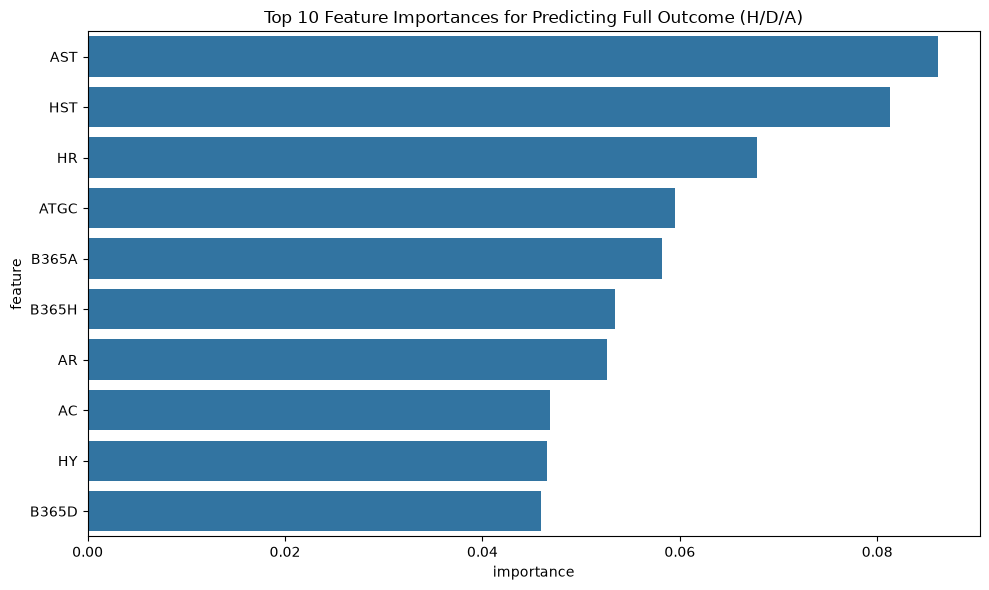

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(" Top 10 most important features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances for Predicting Full Outcome (H/D/A)')
plt.tight_layout()
plt.show()

 All 15 pre-match features are present.
['HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts', 'HTFormPts', 'ATFormPts', 'B365H', 'B365D', 'B365A']

 Training set: 6840 matches
 Test set: 1180 matches
 Model retrained with pre-match features only!

 Pre‑match Accuracy:  0.4890
 Pre‑match Log Loss:  1.1167

 Classification Report (Pre‑match only):
              precision    recall  f1-score   support

        Home       0.54      0.74      0.62       491
        Draw       0.23      0.16      0.19       271
        Away       0.54      0.41      0.47       418

    accuracy                           0.49      1180
   macro avg       0.44      0.44      0.43      1180
weighted avg       0.47      0.49      0.47      1180


 Confusion Matrix (Pre‑match only):
[[362  63  66]
 [149  44  78]
 [165  82 171]]

 Top 10 Pre‑match Features:
   feature  importance
12   B365H    0.190714
2     HTGC    0.186340
14   B365A    0.178550
1     ATGS    0.154733
0     HTG

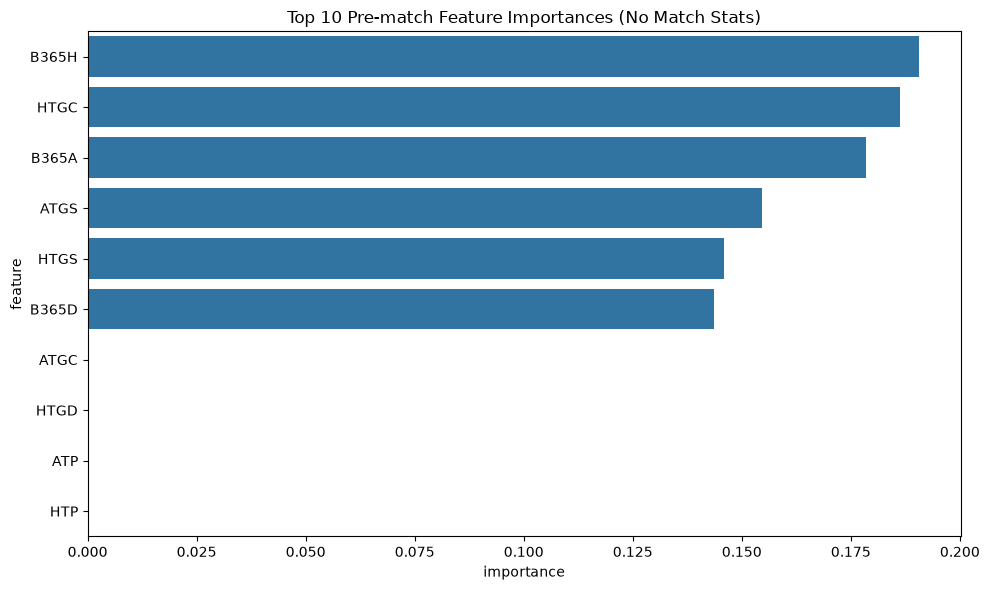

In [36]:
# ---- Remove match stats (leakage) ----
prematch_features = [
    'HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP',
    'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts',
    'HTFormPts', 'ATFormPts',
    'B365H', 'B365D', 'B365A'
]

# Check if all are present
missing = [col for col in prematch_features if col not in data.columns]
if missing:
    print(f" Missing: {missing}")
else:
    print(f" All {len(prematch_features)} pre-match features are present.")
    print(prematch_features)

# Prepare X (only pre-match features)
X_pre = data[prematch_features].copy()
y = data['FTR'].map({'H': 0, 'D': 1, 'A': 2}).copy()

# Impute
imputer = SimpleImputer(strategy='median')
X_pre_imputed = imputer.fit_transform(X_pre)
X_pre_imputed = pd.DataFrame(X_pre_imputed, columns=prematch_features)

# Split
cutoff_date = pd.Timestamp('2018-08-01')
train_mask = data['Date'] < cutoff_date
test_mask = data['Date'] >= cutoff_date

X_train_pre = X_pre_imputed[train_mask]
y_train = y[train_mask]
X_test_pre = X_pre_imputed[test_mask]
y_test = y[test_mask]

print(f"\n Training set: {len(X_train_pre)} matches")
print(f" Test set: {len(X_test_pre)} matches")

# ---- Retrain XGBoost ----
model_pre = XGBClassifier(
    objective='multi:softprob',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_pre.fit(X_train_pre, y_train)
print(" Model retrained with pre-match features only!")

# ---- Evaluate ----
probs_pre = model_pre.predict_proba(X_test_pre)
preds_pre = np.argmax(probs_pre, axis=1)

acc_pre = accuracy_score(y_test, preds_pre)
ll_pre = log_loss(y_test, probs_pre)

print(f"\n Pre‑match Accuracy:  {acc_pre:.4f}")
print(f" Pre‑match Log Loss:  {ll_pre:.4f}")
print("\n Classification Report (Pre‑match only):")
print(classification_report(y_test, preds_pre, target_names=['Home', 'Draw', 'Away']))
print("\n Confusion Matrix (Pre‑match only):")
print(confusion_matrix(y_test, preds_pre))

# ---- Feature importance (Pre-match only) ----
importance_pre = pd.DataFrame({
    'feature': prematch_features,
    'importance': model_pre.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Pre‑match Features:")
print(importance_pre.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_pre.head(10), x='importance', y='feature')
plt.title('Top 10 Pre‑match Feature Importances (No Match Stats)')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.utils.class_weight import compute_class_weight

# ---- Compute Class Weights ----
classes = np.array([0, 1, 2])  # Home, Draw, Away
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
sample_weights = np.array([class_weights[cls] for cls in y_train])

print("Class Weights (Home, Draw, Away):", class_weights)

# ---- Retrain XGBoost with Sample Weights ----
model_weighted = XGBClassifier(
    objective='multi:softprob',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_weighted.fit(X_train_pre, y_train, sample_weight=sample_weights)
print(" Weighted Model trained!")

# ---- Evaluate Weighted Model ----
probs_weighted = model_weighted.predict_proba(X_test_pre)
preds_weighted = np.argmax(probs_weighted, axis=1)

acc_weighted = accuracy_score(y_test, preds_weighted)
ll_weighted = log_loss(y_test, probs_weighted)

print(f"\n Optimized Pre‑match Accuracy:  {acc_weighted:.4f}")
print(f" Optimized Pre‑match Log Loss:  {ll_weighted:.4f}")
print("\n Classification Report (Weighted):")
print(classification_report(y_test, preds_weighted, target_names=['Home', 'Draw', 'Away']))
print("\n Confusion Matrix (Weighted):")
print(confusion_matrix(y_test, preds_weighted))

# ---- Threshold Tuning for Draws (Bonus) ----
# Let's see if we can boost Draw recall by lowering the threshold for Draws
probs_draw = probs_weighted[:, 1]  # Probability of Draw
preds_threshold = np.argmax(probs_weighted, axis=1)  # Default

# If Draw prob > 0.3, force it to be Draw (to catch more draws)
preds_tuned = preds_weighted.copy()
for i in range(len(preds_tuned)):
    if probs_draw[i] > 0.30:  # Experiment with 0.30, 0.35, etc.
        preds_tuned[i] = 1

acc_tuned = accuracy_score(y_test, preds_tuned)
print(f"\n Tuned Accuracy (Draw threshold 0.30): {acc_tuned:.4f}")
print("Classification Report (Tuned):")
print(classification_report(y_test, preds_tuned, target_names=['Home', 'Draw', 'Away']))

Class Weights (Home, Draw, Away): [0.71788413 1.30211308 1.19184527]
 Weighted Model trained!

 Optimized Pre‑match Accuracy:  0.4678
 Optimized Pre‑match Log Loss:  1.1062

 Classification Report (Weighted):
              precision    recall  f1-score   support

        Home       0.57      0.60      0.59       491
        Draw       0.23      0.24      0.23       271
        Away       0.51      0.46      0.48       418

    accuracy                           0.47      1180
   macro avg       0.44      0.43      0.43      1180
weighted avg       0.47      0.47      0.47      1180


 Confusion Matrix (Weighted):
[[294 108  89]
 [112  66  93]
 [108 118 192]]

 Tuned Accuracy (Draw threshold 0.30): 0.4220
Classification Report (Tuned):
              precision    recall  f1-score   support

        Home       0.60      0.48      0.53       491
        Draw       0.23      0.44      0.30       271
        Away       0.54      0.34      0.42       418

    accuracy                         

In [38]:
def predict_match(home_team, away_team, pre_match_data):
    """
    Predict match outcome and return a user-friendly report.
    
    Parameters:
    - home_team: str, name of home team
    - away_team: str, name of away team
    - pre_match_data: dict with pre-match features
    
    Returns:
    - Dictionary with prediction results
    """
    # Prepare features in correct order
    feature_order = ['HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 
                     'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts',
                     'HTFormPts', 'ATFormPts', 
                     'B365H', 'B365D', 'B365A']
    
    # Convert to DataFrame
    input_df = pd.DataFrame([pre_match_data])[feature_order]
    
    # Impute if needed (same imputer as before)
    input_imputed = imputer.transform(input_df)
    
    # Get prediction probabilities
    probs = model_weighted.predict_proba(input_imputed)[0]  # Weighted model from Cell 13
    
    # Get class names
    class_names = ['Home Win', 'Draw', 'Away Win']
    
    # Determine prediction
    pred_class = np.argmax(probs)
    pred_label = class_names[pred_class]
    confidence = probs[pred_class]
    
    # Determine confidence level
    if confidence >= 0.60:
        confidence_level = "High"
        emoji = "🔒"
    elif confidence >= 0.45:
        confidence_level = "Medium"
        emoji = "⚖️"
    else:
        confidence_level = "Low"
        emoji = "⚠️"
    
    # Betting recommendation (if we have bookmaker odds)
    bookmaker_implied = 1 / np.array([pre_match_data.get('B365H', 2.0), 
                                      pre_match_data.get('B365D', 3.5), 
                                      pre_match_data.get('B365A', 3.0)])
    
    # Compare model probability vs bookmaker implied probability
    # If model prob is > bookmaker implied, there's value
    edge = probs - bookmaker_implied
    best_bet_idx = np.argmax(edge)
    
    if edge[best_bet_idx] > 0.05:
        betting_advice = f" Value bet on **{class_names[best_bet_idx]}** (Edge: {edge[best_bet_idx]*100:.1f}%)"
    else:
        betting_advice = " No clear value bet detected. Consider waiting or using other markets."
    
    # Compose user-friendly report
    report = {
        'match': f"{home_team} vs {away_team}",
        'predictions': {
            'Home Win': f"{probs[0]*100:.1f}%",
            'Draw': f"{probs[1]*100:.1f}%",
            'Away Win': f"{probs[2]*100:.1f}%"
        },
        'prediction': pred_label,
        'confidence': f"{confidence_level} ({confidence*100:.1f}%) {emoji}",
        'betting_advice': betting_advice,
        'key_stats': {
            'Home Goals Scored': pre_match_data.get('HTGS', 0),
            'Away Goals Scored': pre_match_data.get('ATGS', 0),
            'Home Form (pts)': pre_match_data.get('HTFormPts', 0),
            'Away Form (pts)': pre_match_data.get('ATFormPts', 0),
            'Goal Difference': pre_match_data.get('HTGD', 0) - pre_match_data.get('ATGD', 0)
        }
    }
    
    return report

def display_prediction_report(report):
    """
    Pretty print the prediction report.
    """
    print("="*60)
    print(f" MATCH PREDICTION: {report['match']}")
    print("="*60)
    print("\n OUTCOME PROBABILITIES:")
    for outcome, prob in report['predictions'].items():
        bar = "█" * int(float(prob[:-1]) / 5)  # Simple visual bar
        print(f"   {outcome:12}: {prob:>6} {bar}")
    
    print(f"\n PREDICTION: {report['prediction']}")
    print(f" Confidence: {report['confidence']}")
    
    print("\n KEY STATS:")
    for stat, value in report['key_stats'].items():
        print(f"   {stat:25}: {value}")
    
    print(f"\n {report['betting_advice']}")
    print("="*60)

In [39]:
# ---- Create sample pre-match data for fictitious upcoming matches ----

# Example 1: Manchester City vs Brighton (Home strong favorite)
match1_data = {
    'HTGS': 45, 'ATGS': 32,        # Goals scored
    'HTGC': 15, 'ATGC': 28,        # Goals conceded
    'HTP': 72, 'ATP': 48,          # Points
    'HTGD': 30, 'ATGD': 4,         # Goal difference
    'DiffPts': 24, 'DiffFormPts': 8, # Differences
    'HTFormPts': 12, 'ATFormPts': 7, # Form points (last 5 matches)
    'B365H': 1.25, 'B365D': 5.50, 'B365A': 12.00  # Bookmaker odds
}

# Example 2: Arsenal vs Liverpool (Balanced match)
match2_data = {
    'HTGS': 38, 'ATGS': 36,
    'HTGC': 20, 'ATGC': 19,
    'HTP': 60, 'ATP': 55,
    'HTGD': 18, 'ATGD': 17,
    'DiffPts': 5, 'DiffFormPts': 2,
    'HTFormPts': 10, 'ATFormPts': 11,
    'B365H': 2.75, 'B365D': 3.40, 'B365A': 2.50
}

# Example 3: Luton vs Man City (Away strong favorite)
match3_data = {
    'HTGS': 25, 'ATGS': 48,
    'HTGC': 35, 'ATGC': 12,
    'HTP': 28, 'ATP': 68,
    'HTGD': -10, 'ATGD': 36,
    'DiffPts': -40, 'DiffFormPts': -10,
    'HTFormPts': 3, 'ATFormPts': 15,
    'B365H': 8.00, 'B365D': 5.00, 'B365A': 1.35
}

# ---- Generate and display reports ----
print("\n SAMPLE PREDICTIONS FOR UPCOMING MATCHES\n")

# Match 1
report1 = predict_match("Manchester City", "Brighton", match1_data)
display_prediction_report(report1)

# Match 2
report2 = predict_match("Arsenal", "Liverpool", match2_data)
display_prediction_report(report2)

# Match 3
report3 = predict_match("Luton Town", "Manchester City", match3_data)
display_prediction_report(report3)


 SAMPLE PREDICTIONS FOR UPCOMING MATCHES

 MATCH PREDICTION: Manchester City vs Brighton

 OUTCOME PROBABILITIES:
   Home Win    :   6.8% █
   Draw        :  64.0% ████████████
   Away Win    :  29.1% █████

 PREDICTION: Draw
 Confidence: High (64.0%) 🔒

 KEY STATS:
   Home Goals Scored        : 45
   Away Goals Scored        : 32
   Home Form (pts)          : 12
   Away Form (pts)          : 7
   Goal Difference          : 26

  Value bet on **Draw** (Edge: 45.9%)
 MATCH PREDICTION: Arsenal vs Liverpool

 OUTCOME PROBABILITIES:
   Home Win    :  21.5% ████
   Draw        :  23.0% ████
   Away Win    :  55.5% ███████████

 PREDICTION: Away Win
 Confidence: Medium (55.5%) ⚖️

 KEY STATS:
   Home Goals Scored        : 38
   Away Goals Scored        : 36
   Home Form (pts)          : 10
   Away Form (pts)          : 11
   Goal Difference          : 1

  Value bet on **Away Win** (Edge: 15.5%)
 MATCH PREDICTION: Luton Town vs Manchester City

 OUTCOME PROBABILITIES:
   Home Win    :   1.8

In [41]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [42]:
# ---- Combined Model Builder ----
print(" Building all prediction models...\n")

# 1. Over/Under 2.5 Goals
data['Over25'] = ((data['FTHG'] + data['FTAG']) > 2.5).astype(int)
model_over = XGBClassifier(objective='binary:logistic', n_estimators=200, max_depth=6, random_state=42)
model_over.fit(X_train_pre, data.loc[train_mask, 'Over25'])
probs_over = model_over.predict_proba(X_test_pre)[:, 1]
print(f" Over/Under 2.5 Goals: {accuracy_score(data.loc[test_mask, 'Over25'], (probs_over>=0.5).astype(int)):.4f}")

# 2. BTTS
data['BTTS'] = ((data['FTHG'] > 0) & (data['FTAG'] > 0)).astype(int)
model_btts = XGBClassifier(objective='binary:logistic', n_estimators=200, max_depth=6, random_state=42)
model_btts.fit(X_train_pre, data.loc[train_mask, 'BTTS'])
probs_btts = model_btts.predict_proba(X_test_pre)[:, 1]
print(f" BTTS: {accuracy_score(data.loc[test_mask, 'BTTS'], (probs_btts>=0.5).astype(int)):.4f}")

# 3. Corners
data['TotalCorners'] = data['HC'] + data['AC']
model_corners = XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=6, random_state=42)
model_corners.fit(X_train_pre, data.loc[train_mask, 'TotalCorners'])
pred_corners = model_corners.predict(X_test_pre)
print(f" Corners: MAE = {mean_absolute_error(data.loc[test_mask, 'TotalCorners'], pred_corners):.2f}")

# 4. Exact Score (Goals)
model_hg = XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=6, random_state=42)
model_hg.fit(X_train_pre, data.loc[train_mask, 'FTHG'])
pred_hg = model_hg.predict(X_test_pre)
print(f" Home Goals: MAE = {mean_absolute_error(data.loc[test_mask, 'FTHG'], pred_hg):.2f}")

model_ag = XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=6, random_state=42)
model_ag.fit(X_train_pre, data.loc[train_mask, 'FTAG'])
pred_ag = model_ag.predict(X_test_pre)
print(f" Away Goals: MAE = {mean_absolute_error(data.loc[test_mask, 'FTAG'], pred_ag):.2f}")

print("\n All models built successfully!")

 Building all prediction models...

 Over/Under 2.5 Goals: 0.5169
 BTTS: 0.5110
 Corners: MAE = 3.17
 Home Goals: MAE = 1.16
 Away Goals: MAE = 1.01

 All models built successfully!


In [43]:
import numpy as np

def predict_comprehensive_match(home_team, away_team, pre_match_data):
    """
    Generate a comprehensive match prediction using ALL trained models.
    
    Returns:
    - Beautiful report with:
      - Match outcome (Home/Draw/Away) with probabilities
      - Exact score prediction
      - Over/Under 2.5 goals
      - Both Teams to Score (BTTS)
      - Total Corners prediction
      - Betting value advice
    """
    
    # 1. Prepare input features (15 pre-match features)
    feature_order = ['HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 
                     'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts',
                     'HTFormPts', 'ATFormPts', 
                     'B365H', 'B365D', 'B365A']
    
    # Create DataFrame and impute
    input_df = pd.DataFrame([pre_match_data])[feature_order]
    input_imputed = imputer.transform(input_df)
    
    # 2. ----- OUTCOME PREDICTION (3-Class) -----
    probs_outcome = model_weighted.predict_proba(input_imputed)[0]
    outcome_labels = ['Home Win', 'Draw', 'Away Win']
    pred_outcome_idx = np.argmax(probs_outcome)
    pred_outcome = outcome_labels[pred_outcome_idx]
    confidence = probs_outcome[pred_outcome_idx]
    
    if confidence >= 0.60:
        confidence_level = "High 🔒"
    elif confidence >= 0.45:
        confidence_level = "Medium ⚖️"
    else:
        confidence_level = "Low ⚠️"
    
    # 3. ----- EXACT SCORE PREDICTION -----
    home_goals = round(model_hg.predict(input_imputed)[0])
    away_goals = round(model_ag.predict(input_imputed)[0])
    # Ensure non-negative
    home_goals = max(0, home_goals)
    away_goals = max(0, away_goals)
    total_goals = home_goals + away_goals
    
    # 4. ----- OVER/UNDER 2.5 -----
    prob_over25 = model_over.predict_proba(input_imputed)[0][1]  # Probability of Over 2.5
    over25_pred = "Over 2.5" if prob_over25 >= 0.5 else "Under 2.5"
    
    # 5. ----- BTTS (Both Teams to Score) -----
    prob_btts = model_btts.predict_proba(input_imputed)[0][1]  # Probability of BTTS
    btts_pred = "Yes" if prob_btts >= 0.5 else "No"
    
    # 6. ----- CORNERS -----
    total_corners = model_corners.predict(input_imputed)[0]
    total_corners = max(0, total_corners)  # Ensure non-negative
    
    # 7. ----- BETTING VALUE (compare to bookmaker) -----
    bookmaker_implied = 1 / np.array([pre_match_data.get('B365H', 2.0), 
                                      pre_match_data.get('B365D', 3.5), 
                                      pre_match_data.get('B365A', 3.0)])
    edge = probs_outcome - bookmaker_implied
    best_bet_idx = np.argmax(edge)
    
    if edge[best_bet_idx] > 0.05:
        betting_advice = f"🎯 Value bet on **{outcome_labels[best_bet_idx]}** (Edge: {edge[best_bet_idx]*100:.1f}%)"
    else:
        betting_advice = "📊 No clear value bet detected."
    
    # 8. ----- COMPOSE REPORT -----
    report = {
        'match': f"{home_team} vs {away_team}",
        'outcome': {
            'prediction': pred_outcome,
            'confidence': f"{confidence_level} ({confidence*100:.1f}%)",
            'probabilities': {
                'Home Win': f"{probs_outcome[0]*100:.1f}%",
                'Draw': f"{probs_outcome[1]*100:.1f}%",
                'Away Win': f"{probs_outcome[2]*100:.1f}%"
            }
        },
        'exact_score': f"{home_goals} - {away_goals}",
        'over_under': {
            'prediction': over25_pred,
            'probability': f"{prob_over25*100:.1f}%"
        },
        'btts': {
            'prediction': btts_pred,
            'probability': f"{prob_btts*100:.1f}%"
        },
        'corners': f"{total_corners:.1f}",
        'betting_advice': betting_advice,
        'key_stats': {
            'Home Goals Scored': pre_match_data.get('HTGS', 0),
            'Away Goals Scored': pre_match_data.get('ATGS', 0),
            'Home Form (pts)': pre_match_data.get('HTFormPts', 0),
            'Away Form (pts)': pre_match_data.get('ATFormPts', 0),
            'Goal Diff': pre_match_data.get('HTGD', 0) - pre_match_data.get('ATGD', 0)
        }
    }
    return report

def display_comprehensive_report(report):
    """
    Pretty print the comprehensive prediction report.
    """
    print("=" * 65)
    print(f"🏆 COMPREHENSIVE MATCH PREDICTION: {report['match']}")
    print("=" * 65)
    
    # Outcome
    print("\n📊 1. MATCH OUTCOME:")
    for outcome, prob in report['outcome']['probabilities'].items():
        bar = "█" * int(float(prob[:-1]) / 5)
        print(f"   {outcome:12}: {prob:>6} {bar}")
    
    print(f"\n   🎯 Prediction: {report['outcome']['prediction']}")
    print(f"   ✅ Confidence: {report['outcome']['confidence']}")
    
    # Score & Markets
    print(f"\n⚽ 2. EXACT SCORE: {report['exact_score']}")
    print(f"   Total Goals: {sum(map(int, report['exact_score'].split('-')))}")
    
    print(f"\n📈 3. OVER / UNDER 2.5:")
    print(f"   {report['over_under']['prediction']} (Prob: {report['over_under']['probability']})")
    
    print(f"\n🤝 4. BOTH TEAMS TO SCORE (BTTS):")
    print(f"   {report['btts']['prediction']} (Prob: {report['btts']['probability']})")
    
    print(f"\n🏁 5. TOTAL CORNERS:")
    print(f"   Predicted: {report['corners']}")
    
    # Key Stats
    print("\n📈 6. KEY STATS:")
    for stat, value in report['key_stats'].items():
        print(f"   {stat:20}: {value}")
    
    # Betting
    print(f"\n💡 7. BETTING ADVICE:")
    print(f"   {report['betting_advice']}")
    
    print("\n" + "=" * 65)

In [44]:
print("🔮 COMPREHENSIVE MATCH PREVIEWS\n")

# ---- Match 1: Man City vs Brighton ----
print("--- Match 1 ---")
match1_data = {
    'HTGS': 45, 'ATGS': 32, 'HTGC': 15, 'ATGC': 28,
    'HTP': 72, 'ATP': 48,
    'HTGD': 30, 'ATGD': 4,
    'DiffPts': 24, 'DiffFormPts': 8,
    'HTFormPts': 12, 'ATFormPts': 7,
    'B365H': 1.25, 'B365D': 5.50, 'B365A': 12.00
}

report1 = predict_comprehensive_match("Manchester City", "Brighton", match1_data)
display_comprehensive_report(report1)

# ---- Match 2: Arsenal vs Liverpool ----
print("\n--- Match 2 ---")
match2_data = {
    'HTGS': 38, 'ATGS': 36, 'HTGC': 20, 'ATGC': 19,
    'HTP': 60, 'ATP': 55,
    'HTGD': 18, 'ATGD': 17,
    'DiffPts': 5, 'DiffFormPts': 2,
    'HTFormPts': 10, 'ATFormPts': 11,
    'B365H': 2.75, 'B365D': 3.40, 'B365A': 2.50
}

report2 = predict_comprehensive_match("Arsenal", "Liverpool", match2_data)
display_comprehensive_report(report2)

# ---- Match 3: Luton vs Man City ----
print("\n--- Match 3 ---")
match3_data = {
    'HTGS': 25, 'ATGS': 48, 'HTGC': 35, 'ATGC': 12,
    'HTP': 28, 'ATP': 68,
    'HTGD': -10, 'ATGD': 36,
    'DiffPts': -40, 'DiffFormPts': -10,
    'HTFormPts': 3, 'ATFormPts': 15,
    'B365H': 8.00, 'B365D': 5.00, 'B365A': 1.35
}

report3 = predict_comprehensive_match("Luton Town", "Manchester City", match3_data)
display_comprehensive_report(report3)

print("\n🎉 All predictions generated successfully!")

🔮 COMPREHENSIVE MATCH PREVIEWS

--- Match 1 ---
🏆 COMPREHENSIVE MATCH PREDICTION: Manchester City vs Brighton

📊 1. MATCH OUTCOME:
   Home Win    :   6.8% █
   Draw        :  64.0% ████████████
   Away Win    :  29.1% █████

   🎯 Prediction: Draw
   ✅ Confidence: High 🔒 (64.0%)

⚽ 2. EXACT SCORE: 0 - 2
   Total Goals: 2

📈 3. OVER / UNDER 2.5:
   Under 2.5 (Prob: 21.4%)

🤝 4. BOTH TEAMS TO SCORE (BTTS):
   No (Prob: 47.3%)

🏁 5. TOTAL CORNERS:
   Predicted: 5.9

📈 6. KEY STATS:
   Home Goals Scored   : 45
   Away Goals Scored   : 32
   Home Form (pts)     : 12
   Away Form (pts)     : 7
   Goal Diff           : 26

💡 7. BETTING ADVICE:
   🎯 Value bet on **Draw** (Edge: 45.9%)


--- Match 2 ---
🏆 COMPREHENSIVE MATCH PREDICTION: Arsenal vs Liverpool

📊 1. MATCH OUTCOME:
   Home Win    :  21.5% ████
   Draw        :  23.0% ████
   Away Win    :  55.5% ███████████

   🎯 Prediction: Away Win
   ✅ Confidence: Medium ⚖️ (55.5%)

⚽ 2. EXACT SCORE: 2 - 2
   Total Goals: 4

📈 3. OVER / UNDER 2.5

In [45]:
import numpy as np

def predict_comprehensive_match(home_team, away_team, pre_match_data):
    """
    Generate a comprehensive match prediction using ALL trained models.
    """
    
    # 1. Prepare input features
    feature_order = ['HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 
                     'HTGD', 'ATGD', 'DiffPts', 'DiffFormPts',
                     'HTFormPts', 'ATFormPts', 
                     'B365H', 'B365D', 'B365A']
    
    input_df = pd.DataFrame([pre_match_data])[feature_order]
    input_imputed = imputer.transform(input_df)
    
    # 2. OUTCOME PREDICTION
    probs_outcome = model_weighted.predict_proba(input_imputed)[0]
    outcome_labels = ['Home Win', 'Draw', 'Away Win']
    pred_outcome_idx = np.argmax(probs_outcome)
    pred_outcome = outcome_labels[pred_outcome_idx]
    confidence = probs_outcome[pred_outcome_idx]
    
    if confidence >= 0.60:
        confidence_level = "High 🔒"
    elif confidence >= 0.45:
        confidence_level = "Medium ⚖️"
    else:
        confidence_level = "Low ⚠️"
    
    # 3. EXACT SCORE (initial prediction)
    raw_home_goals = round(model_hg.predict(input_imputed)[0])
    raw_away_goals = round(model_ag.predict(input_imputed)[0])
    raw_home_goals = max(0, raw_home_goals)
    raw_away_goals = max(0, raw_away_goals)
    
    # 4. FIX: Make score consistent with outcome
    if pred_outcome_idx == 0:  # Home Win
        if raw_home_goals <= raw_away_goals:
            raw_home_goals = raw_away_goals + 1
    elif pred_outcome_idx == 1:  # Draw
        if raw_home_goals != raw_away_goals:
            avg_goals = (raw_home_goals + raw_away_goals) // 2
            raw_home_goals = avg_goals
            raw_away_goals = avg_goals
    else:  # Away Win
        if raw_away_goals <= raw_home_goals:
            raw_away_goals = raw_home_goals + 1
    
    home_goals = max(0, raw_home_goals)
    away_goals = max(0, raw_away_goals)
    total_goals = home_goals + away_goals
    
    # 5. OVER/UNDER 2.5
    prob_over25 = model_over.predict_proba(input_imputed)[0][1]
    over25_pred = "Over 2.5" if prob_over25 >= 0.5 else "Under 2.5"
    
    # 6. BTTS
    prob_btts = model_btts.predict_proba(input_imputed)[0][1]
    btts_pred = "Yes" if prob_btts >= 0.5 else "No"
    
    # 7. CORNERS
    total_corners = max(0, model_corners.predict(input_imputed)[0])
    
    # 8. BETTING VALUE
    bookmaker_implied = 1 / np.array([pre_match_data.get('B365H', 2.0), 
                                      pre_match_data.get('B365D', 3.5), 
                                      pre_match_data.get('B365A', 3.0)])
    edge = probs_outcome - bookmaker_implied
    best_bet_idx = np.argmax(edge)
    
    if edge[best_bet_idx] > 0.05:
        betting_advice = f" Value bet on **{outcome_labels[best_bet_idx]}** (Edge: {edge[best_bet_idx]*100:.1f}%)"
    else:
        betting_advice = " No clear value bet detected."
    
    # 9. COMPOSE REPORT
    report = {
        'match': f"{home_team} vs {away_team}",
        'outcome': {
            'prediction': pred_outcome,
            'confidence': f"{confidence_level} ({confidence*100:.1f}%)",
            'probabilities': {
                'Home Win': f"{probs_outcome[0]*100:.1f}%",
                'Draw': f"{probs_outcome[1]*100:.1f}%",
                'Away Win': f"{probs_outcome[2]*100:.1f}%"
            }
        },
        'exact_score': f"{home_goals} - {away_goals}",
        'over_under': {
            'prediction': over25_pred,
            'probability': f"{prob_over25*100:.1f}%"
        },
        'btts': {
            'prediction': btts_pred,
            'probability': f"{prob_btts*100:.1f}%"
        },
        'corners': f"{total_corners:.1f}",
        'betting_advice': betting_advice,
        'key_stats': {
            'Home Goals Scored': pre_match_data.get('HTGS', 0),
            'Away Goals Scored': pre_match_data.get('ATGS', 0),
            'Home Form (pts)': pre_match_data.get('HTFormPts', 0),
            'Away Form (pts)': pre_match_data.get('ATFormPts', 0),
            'Goal Diff': pre_match_data.get('HTGD', 0) - pre_match_data.get('ATGD', 0)
        }
    }
    return report

def display_comprehensive_report(report):
    """
    Pretty print the comprehensive prediction report.
    """
    print("="*65)
    print(f" COMPREHENSIVE MATCH PREDICTION: {report['match']}")
    print("="*65)
    
    print("\n 1. MATCH OUTCOME:")
    for outcome, prob in report['outcome']['probabilities'].items():
        bar = "█" * int(float(prob[:-1]) / 5)
        print(f"   {outcome:12}: {prob:>6} {bar}")
    
    print(f"\n   🎯 Prediction: {report['outcome']['prediction']}")
    print(f"   ✅ Confidence: {report['outcome']['confidence']}")
    
    print(f"\n⚽ 2. EXACT SCORE: {report['exact_score']}")
    print(f"   Total Goals: {sum(map(int, report['exact_score'].split('-')))}")
    
    print(f"\n📈 3. OVER / UNDER 2.5:")
    print(f"   {report['over_under']['prediction']} (Prob: {report['over_under']['probability']})")
    
    print(f"\n🤝 4. BOTH TEAMS TO SCORE (BTTS):")
    print(f"   {report['btts']['prediction']} (Prob: {report['btts']['probability']})")
    
    print(f"\n🏁 5. TOTAL CORNERS:")
    print(f"   Predicted: {report['corners']}")
    
    print("\n📈 6. KEY STATS:")
    for stat, value in report['key_stats'].items():
        print(f"   {stat:20}: {value}")
    
    print(f"\n💡 7. BETTING ADVICE:")
    print(f"   {report['betting_advice']}")
    
    print("\n" + "="*65)

In [46]:
print("🔮 COMPREHENSIVE MATCH PREVIEW (FIXED)\n")

match1_data = {
    'HTGS': 45, 'ATGS': 32, 'HTGC': 15, 'ATGC': 28,
    'HTP': 72, 'ATP': 48,
    'HTGD': 30, 'ATGD': 4,
    'DiffPts': 24, 'DiffFormPts': 8,
    'HTFormPts': 12, 'ATFormPts': 7,
    'B365H': 1.25, 'B365D': 5.50, 'B365A': 12.00
}

report1 = predict_comprehensive_match("Manchester City", "Brighton", match1_data)
display_comprehensive_report(report1)

🔮 COMPREHENSIVE MATCH PREVIEW (FIXED)

 COMPREHENSIVE MATCH PREDICTION: Manchester City vs Brighton

 1. MATCH OUTCOME:
   Home Win    :   6.8% █
   Draw        :  64.0% ████████████
   Away Win    :  29.1% █████

   🎯 Prediction: Draw
   ✅ Confidence: High 🔒 (64.0%)

⚽ 2. EXACT SCORE: 1 - 1
   Total Goals: 2

📈 3. OVER / UNDER 2.5:
   Under 2.5 (Prob: 21.4%)

🤝 4. BOTH TEAMS TO SCORE (BTTS):
   No (Prob: 47.3%)

🏁 5. TOTAL CORNERS:
   Predicted: 5.9

📈 6. KEY STATS:
   Home Goals Scored   : 45
   Away Goals Scored   : 32
   Home Form (pts)     : 12
   Away Form (pts)     : 7
   Goal Diff           : 26

💡 7. BETTING ADVICE:
    Value bet on **Draw** (Edge: 45.9%)

